This is the notebook for clustering a two dimensional dataset (Unsupervised learning)

In [5]:
# prepare data:
import numpy as np

x = np.array([
    [1.2, 1.8],
    [1.8, 2.2],
    [2.4, 1.6],
    [1.5, 2.8],
    [2.7, 2.5],
    [2.1, 3.0],
    [0.9, 2.4],
    [2.9, 1.9],
    [1.7, 1.3],
    [2.5, 3.2],

    [6.2, 7.1],
    [7.0, 6.8],
    [7.5, 7.6],
    [6.8, 8.0],
    [8.1, 7.2],
    [7.3, 8.4],
    [6.0, 7.8],
    [8.4, 8.1],
    [7.8, 6.4],
    [6.6, 6.2],

    [9.0, 2.1],
    [8.4, 1.4],
    [9.6, 1.8],
    [8.9, 3.0],
    [10.2, 2.7],
    [9.8, 3.5],
    [8.1, 2.6],
    [10.5, 1.6],
    [9.4, 2.9],
    [8.7, 0.9]
])

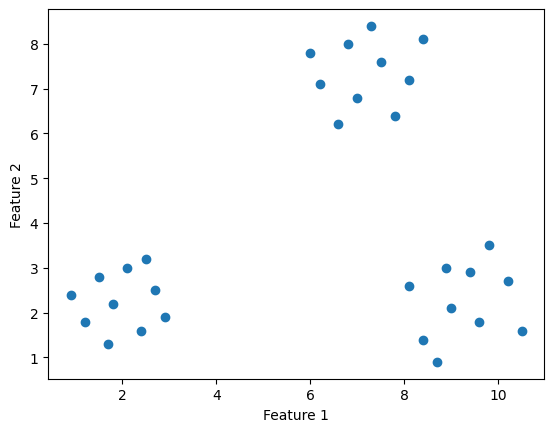

In [9]:
import matplotlib.pyplot as plt
plt.scatter(x[:, 0], x[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

K means Clustering

In [95]:
# initalise centroids randomly across feature space:
# Use K distincy points form dataset to initialise:
def initalise_m(x,K):
    idx = np.random.choice(len(x), size= K, replace=False)
    m= x[idx].copy()
    return m

def assigment_step(x,m):
    z = []
    for xn in x:
        zn_arr = []

        for mk in m:
            zn_arr.append(np.linalg.norm(xn - mk)**2)
        
        zn = np.argmin(np.array(zn_arr))
        z.append(zn)
    
    return np.array(z)

def update_step(x,z,K):
    # Take the average of x with same labels in z,
    #  then set it to m
    m = []
    for i in range(K):
        cluster_i = np.where(z == i)[0]

        if len(cluster_i) == 0:
            mi = x[np.random.choice(len(x))].copy()
        else:
            mi = np.mean(x[cluster_i], axis=0)

        m.append(mi)
    
    return np.array(m)

def loss(x,m,z,K):
    J = 0
    for i in range(K):
        m_zn = m[i]
        x_i = x[np.where(z == i)[0]]
        J += np.linalg.norm(x_i - m_zn)**2
    
    return J


In [96]:
# Now do a single run:
K = 3

def single_run(iterations,x=x):


    m = initalise_m(x,K)

    for iter in range(iterations):

        z = assigment_step(x,m)

        m_new = update_step(x,z,K)

        if np.linalg.norm(m_new - m) < 1e-4:
            m = m_new
            break
        
        m = m_new

    z = assigment_step(x, m)

    J = loss(x, m, z, K)


    #print(f"Learning completed after {iter+1} steps with m= {m} with loss J = {J}")
    return J,m, z


In [97]:
# Now run Multiple runs by restarting:
def run_multiple_runs(K, RUNS, iterations,x=x):

    All_Js = []
    All_ms = []
    All_zs = []
    for run in range(RUNS):
        J, m, z = single_run(iterations)
        All_Js.append(J)
        All_ms.append(m)
        All_zs.append(z)

    return All_Js, All_ms, All_zs


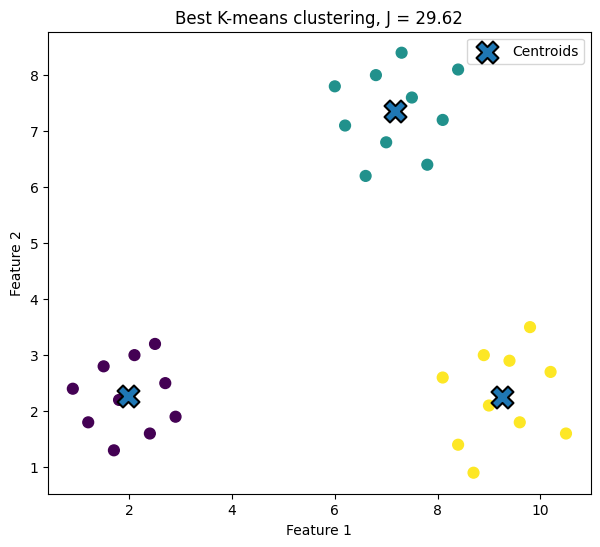

In [98]:
# Select best run:

All_Js, All_ms, All_zs = run_multiple_runs(K=3, RUNS=10,iterations=20)
best_run = np.argmin(np.array(All_Js))

m_best = All_ms[best_run]
z_best = All_zs[best_run]

plt.figure(figsize=(7, 6))

plt.scatter(
    x[:, 0],
    x[:, 1],
    c=z_best,
    cmap="viridis",
    s=60
)

plt.scatter(
    m_best[:, 0],
    m_best[:, 1],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"Best K-means clustering, J = {All_Js[best_run]:.2f}")
plt.legend()
plt.show()

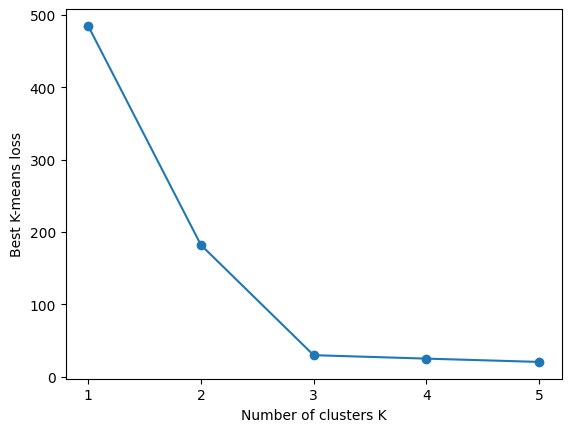

In [111]:
K_vals = [1,2,3,4,5]
best_Js = []
best_ms = []
best_zs = []

for K in K_vals:
    All_Js, All_ms, All_zs = run_multiple_runs(
        K=K,
        RUNS=20,
        iterations=20
    )

    best_run = np.argmin(All_Js)

    best_Js.append(All_Js[best_run])
    best_ms.append(All_ms[best_run])
    best_zs.append(All_zs[best_run])

plt.plot(K_vals, best_Js, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Best K-means loss")
plt.xticks(K_vals)
plt.show()

In [112]:
K_arr = np.array(K_vals, dtype=float)
J_arr = np.array(best_Js, dtype=float)

# Remove failed runs such as NaN values
valid = np.isfinite(J_arr)
K_valid = K_arr[valid]
J_valid = J_arr[valid]

# Normalise both axes so their different scales do not dominate
K_norm = (K_valid - K_valid.min()) / (K_valid.max() - K_valid.min())
J_norm = (J_valid - J_valid.min()) / (J_valid.max() - J_valid.min())

points = np.column_stack((K_norm, J_norm))

line_start = points[0]
line_end = points[-1]
line_vector = line_end - line_start

# Perpendicular distance of every point from the endpoint line
relative_points = points - line_start

distances = np.abs(
    line_vector[0] * relative_points[:, 1]
    - line_vector[1] * relative_points[:, 0]
) / np.linalg.norm(line_vector)

elbow_index = np.argmax(distances)
K_elbow = int(K_valid[elbow_index])

print("Estimated elbow:", K_elbow)

Estimated elbow: 3


In [129]:
import numpy as np

rng = np.random.default_rng(42)

N_per_cluster = 100
d = 8
K_true = 5

true_means = np.array([
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 6,  5,  7,  6,  5,  7,  6,  5],
    [-6,  5, -5,  6, -7,  5, -6,  7],
    [ 5, -6,  6, -5,  7, -6,  5, -7],
    [-5, -6, -7, -5, -6, -7, -5, -6]
], dtype=float)

clusters = []

for mean in true_means:
    cluster = rng.normal(
        loc=mean,
        scale=1.0,
        size=(N_per_cluster, d)
    )
    clusters.append(cluster)

x_high = np.vstack(clusters)

# Shuffle rows so the clusters are not grouped together
rng.shuffle(x_high)

print(x_high.shape)

(500, 8)


In [121]:
from sklearn.cluster import KMeans

K = 5

model = KMeans(
    n_clusters=K,
    init="k-means++",
    n_init=30,
    max_iter=300,
    tol=1e-4,
    random_state=42
)

z = model.fit_predict(x_high)

m = model.cluster_centers_
J = model.inertia_

print("Centroids shape:", m.shape)
print("Labels shape:", z.shape)
print("Final inertia:", J)
print("Iterations used:", model.n_iter_)

Centroids shape: (5, 8)
Labels shape: (500,)
Final inertia: 3953.6672167749693
Iterations used: 2


In [122]:
x_new = np.array([
    [0.2, -0.1, 0.3, 0.0, -0.2, 0.1, 0.2, -0.1]
])

z_new = model.predict(x_new)

print(z_new)

[0]


In [123]:
from sklearn.metrics import silhouette_score

K_vals = range(2, 11)
silhouette_scores = []

for K in K_vals:
    model = KMeans(
        n_clusters=K,
        n_init=30,
        random_state=42
    )

    labels = model.fit_predict(x_high)

    score = silhouette_score(x_high, labels)
    silhouette_scores.append(score)

best_index = np.argmax(silhouette_scores)
best_K = list(K_vals)[best_index]

print("Best K by silhouette:", best_K)

Best K by silhouette: 5


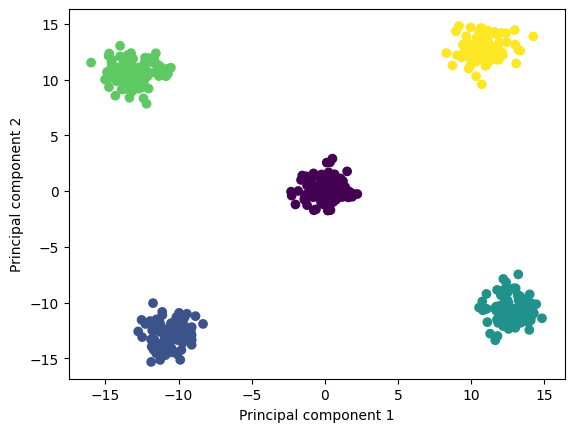

In [141]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
x_2d = pca.fit_transform(x_high)

model = KMeans(
    n_clusters=5,
    n_init=30,
    random_state=42
)

z = model.fit_predict(x_high)

plt.scatter(
    x_2d[:, 0],
    x_2d[:, 1],
    c=z,
    cmap="viridis"
)

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.show()

In [145]:
def PCA(X, M=2):
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    S = (X_centered.T @ X_centered) / len(X_centered)

    eigvals, eigvecs = np.linalg.eigh(S)

    idx = np.argsort(eigvals)[::-1][:M]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    Z = X_centered @ eigvecs

    return Z, eigvals, eigvecs, mean

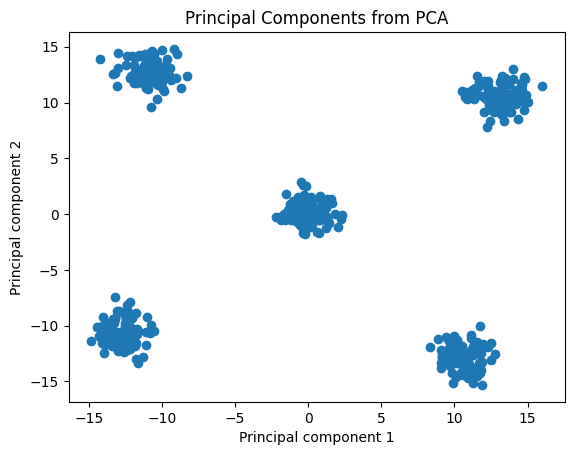

In [146]:
principal_components, eigenvalues, eigenvectors, mean = PCA(x_high, M=2)

plt.plot(principal_components[:, 0], principal_components[:, 1], 'o')
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Principal Components from PCA")
plt.show()                

GMM using EM

In [178]:
def initialise_params(x, K, seed=None):
    rng = np.random.default_rng(seed)

    N, D = x.shape

    # Initial means: choose K distinct datapoints
    indices = rng.choice(N, size=K, replace=False)
    mu_arr = x[indices].copy()

    # Equal mixture weights
    pi_arr = np.full(K, 1.0 / K)

    # Same global covariance for every component
    global_cov = np.cov(x, rowvar=False)

    # Small regularisation for numerical stability
    global_cov += 1e-6 * np.eye(D)

    Sigma_arr = np.repeat(global_cov[None, :, :], K, axis=0)

    return mu_arr, pi_arr, Sigma_arr

def Gaussian(xn, mu, Sigma):

    expo = -0.5 * (xn - mu).T @ np.linalg.inv(Sigma) @ (xn- mu)
    const = 1/((2* np.pi)**(len(xn)/2) * np.sqrt(np.linalg.det(Sigma)))
    
    return  const * np.exp(expo)

def calc__resp(xn, mu,pi,Sigma):
    return pi * Gaussian(xn, mu, Sigma)

def get_sum_resps(xn,mu_arr,pi_arr,Sigma_arr):
    
    tot = 0
    for i in range(len(pi_arr)):
        pi = pi_arr[i]
        mu = mu_arr[i]
        Sigma = Sigma_arr[i]
        tot += calc__resp(xn, mu, pi, Sigma)
    return tot

def E_step(x, mu_arr, pi_arr, Sigma_arr):
    
    # Build R for all responsibilities
    R = []
    for xn in x:

        r_n = []
        Norm = get_sum_resps(xn, mu_arr, pi_arr, Sigma_arr)
        
        for i in range(len(pi_arr)):
            r = calc__resp(xn, mu_arr[i], pi_arr[i], Sigma_arr[i]) / Norm
            r_n.append(r)

        R.append(r_n)

    return np.array(R)

def M_step(R, x):

    Nk = R.sum(axis=0)
    
    mu_arr_new = (R.T @ x) / Nk[:, None]
    
    pi_arr_new = Nk / len(x)

    Sigma_arr_new = np.array([
        ((x - mu_arr_new[k]).T
         @ (R[:, k, None] * (x - mu_arr_new[k])))
        / Nk[k]
        + 1e-6 * np.eye(x.shape[1])
        for k in range(len(Nk))
    ])

    return mu_arr_new, pi_arr_new, Sigma_arr_new

def do_EM_for_GMM(x, K, iterations):

    mu_arr, pi_arr, Sigma_arr = initialise_params(x, K)
    
    for iter in range(iterations):
        
        R = E_step(x, mu_arr, pi_arr, Sigma_arr)

        mu_arr_prev = mu_arr.copy()
        mu_arr, pi_arr, Sigma_arr = M_step(R, x)

        #check for convergence
        if iter > 0 and np.linalg.norm(mu_arr - mu_arr_prev) < 1e-5:
            print(f"Converged after {iter+1} iterations.")
            break
    
    R = E_step(x, mu_arr, pi_arr, Sigma_arr)

    return mu_arr, pi_arr, Sigma_arr, R




In [183]:
# Now conduct GMM on x_high with K=5 and 100 iterations

mu_arr, pi_arr, Sigma_arr, R = do_EM_for_GMM(x_high, K=5, iterations=500)

Converged after 24 iterations.


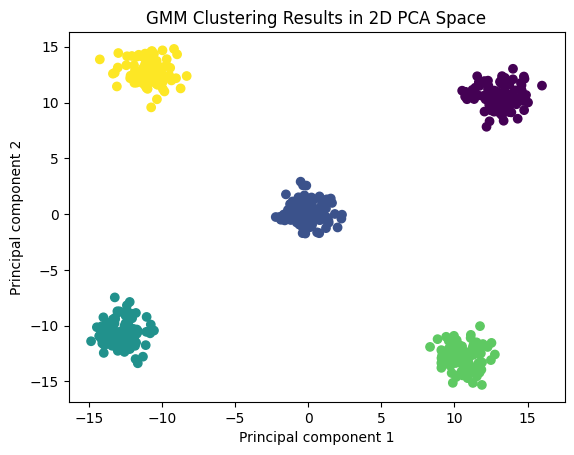

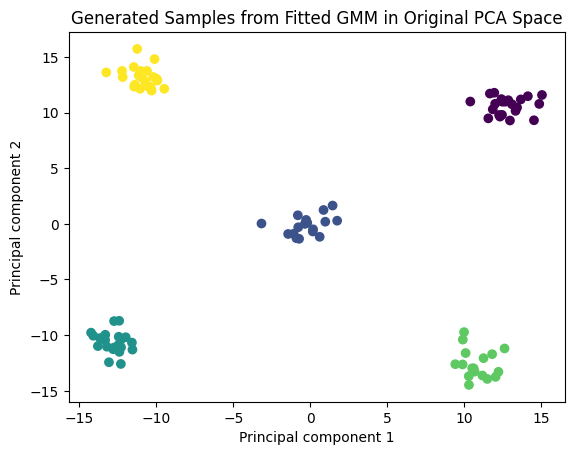

In [184]:
# Fit PCA on the original data
x_2d, eigvals, eigvecs, x_mean = PCA(x_high, M=2)

plt.scatter(
    x_2d[:, 0],
    x_2d[:, 1],
    c=np.argmax(R, axis=1),
    cmap="viridis"
)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("GMM Clustering Results in 2D PCA Space")
plt.show()


# Generate samples from the fitted GMM
N_gen = 100

z_gen = np.random.choice(
    len(pi_arr),
    size=N_gen,
    p=pi_arr
)

x_gen = np.array([
    np.random.multivariate_normal(
        mu_arr[k],
        Sigma_arr[k]
    )
    for k in z_gen
])

# Project using the original PCA basis
x_gen_2d = (x_gen - x_mean) @ eigvecs

plt.scatter(
    x_gen_2d[:, 0],
    x_gen_2d[:, 1],
    c=z_gen,
    cmap="viridis"
)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Generated Samples from Fitted GMM in Original PCA Space")
plt.show()

Now the scratch GMM Generative Model is complete using numpy only, let's call APis for simpler life:

Selected K: 5


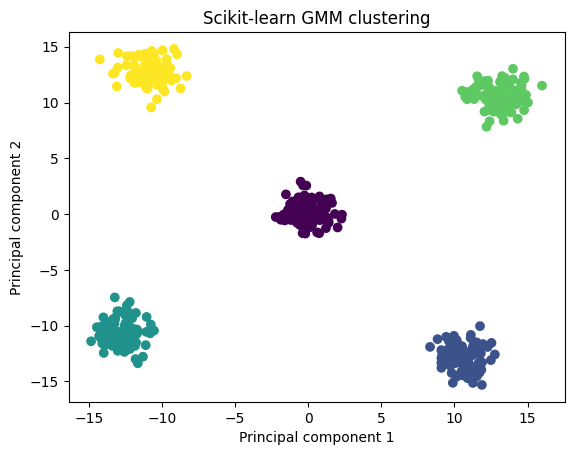

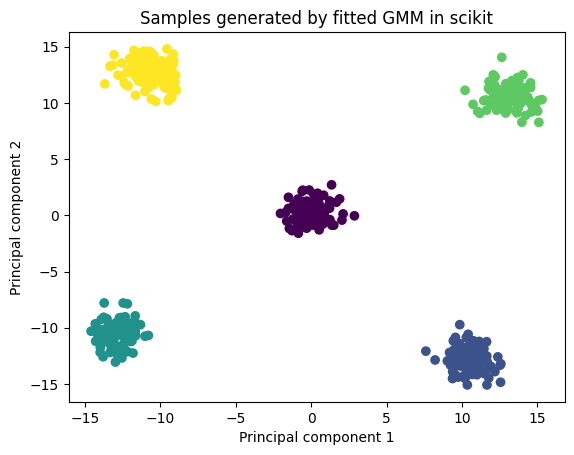

In [189]:
import numpy as np
from sklearn.mixture import GaussianMixture

# Choose best k:

models = []
bic_values = []
aic_values = []

for K in range(1, 11):
    model = GaussianMixture(
        n_components=K,
        covariance_type="full",
        n_init=10,
        reg_covar=1e-6,
        random_state=42
    )

    model.fit(x_high)

    models.append(model)
    bic_values.append(model.bic(x_high))
    aic_values.append(model.aic(x_high))

best_index = np.argmin(aic_values)
best_gmm = models[best_index]

print("Selected K:", best_gmm.n_components)

K = best_gmm.n_components

gmm = GaussianMixture(
    n_components=K,
    covariance_type="full",
    max_iter=200,
    tol=1e-4,
    reg_covar=1e-6,
    n_init=10,
    init_params="k-means++",
    random_state=42
)

gmm.fit(x_high)

R = gmm.predict_proba(x_high)

labels = gmm.predict(x_high)

x_gen, z_gen = gmm.sample(500)

x_2d, eigvals, eigvecs, x_mean = PCA(x_high, M=2)

plt.scatter(
    x_2d[:, 0],
    x_2d[:, 1],
    c=labels,
    cmap="viridis"
)

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Scikit-learn GMM clustering")
plt.show()

x_gen_2d = (x_gen - x_mean) @ eigvecs

plt.scatter(
    x_gen_2d[:, 0],
    x_gen_2d[:, 1],
    c=z_gen,
    cmap="viridis"
)

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Samples generated by fitted GMM in scikit")
plt.show()